# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

## 🔄 What changed in this version
All beginner tasks have been applied:
1. Corpus replaced with a larger, themed deep-learning paragraph
2. Embedding dimension increased `32 -> 100`
3. Epochs increased `100 -> 200`
4. Hidden units increased `64 -> 128` (RNN, LSTM, GRU)
5. Text generation now produces `10` words instead of `5`

Small fix: removed the deprecated `input_length` argument from `Embedding` so the notebook runs on current Keras 3 / TensorFlow 2.16+ without errors.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We now use a **larger themed corpus** (deep learning topic) so the models have more
patterns to learn from. You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence across many industries
recurrent neural networks are useful for modelling sequential data
long short term memory networks help remember long term dependencies
gru networks are faster and simpler than lstm networks
text generation models learn to predict the next word in a sentence
deep learning models can generate meaningful and coherent sentences
sequence models capture grammar context and word order
embeddings represent words as dense numerical vectors
the softmax layer outputs a probability for every word in the vocabulary
training a language model means minimising the prediction loss
attention mechanisms later improved sequence modelling even further
transformers replaced recurrent networks in many modern systems
but understanding rnn lstm and gru builds strong intuition
gradient descent slowly updates the weights during training
a larger corpus usually helps the model learn better patterns
'''
print(corpus)


deep learning is transforming artificial intelligence across many industries
recurrent neural networks are useful for modelling sequential data
long short term memory networks help remember long term dependencies
gru networks are faster and simpler than lstm networks
text generation models learn to predict the next word in a sentence
deep learning models can generate meaningful and coherent sentences
sequence models capture grammar context and word order
embeddings represent words as dense numerical vectors
the softmax layer outputs a probability for every word in the vocabulary
training a language model means minimising the prediction loss
attention mechanisms later improved sequence modelling even further
transformers replaced recurrent networks in many modern systems
but understanding rnn lstm and gru builds strong intuition
gradient descent slowly updates the weights during training
a larger corpus usually helps the model learn better patterns



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 102
X shape: (122, 11)
y shape: (122,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

(Now using embedding dim 100, 128 hidden units, 200 epochs.)

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 100),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 100),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 100),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

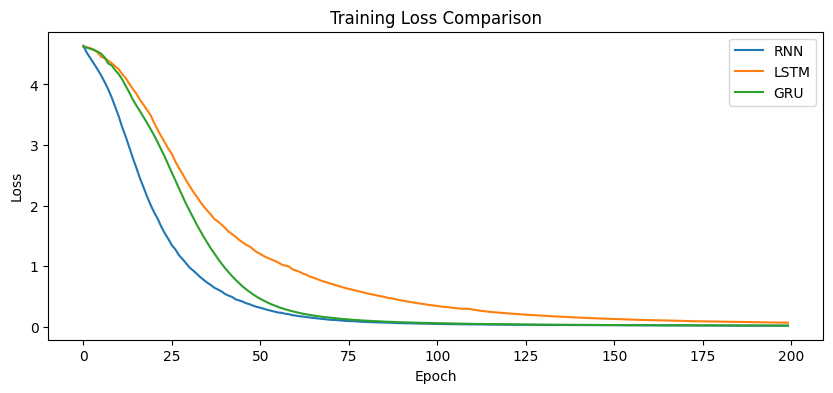

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.
Default length is now **10 words**.

In [8]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning is transforming artificial intelligence across many industries systems dependencies the
LSTM: deep learning models can generate meaningful and coherent sentences sentences sentences vocabulary
GRU : deep learning models can generate meaningful and coherent sentences sentences sentences sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks (already applied in this version)
1. ~~Replace corpus with your own paragraph~~ done
2. ~~Increase embedding dimension~~ done (32 -> 100)
3. ~~Increase epochs to 200~~ done
4. ~~Change hidden units 64 -> 128~~ done
5. ~~Generate 10 words instead of 5~~ done

### 🔧 Try Next (intermediate)
6. Add a second recurrent layer (use `return_sequences=True` on the first layer)
7. Add `Dropout(0.2)` to reduce overfitting on the small corpus
8. Try temperature based sampling instead of `argmax` for more creative text
9. Plot accuracy alongside loss
10. Save the best model with `ModelCheckpoint`

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**